In [ ]:


import feedparser

# L'URL correcte pointe vers le flux RSS (XML) de l'ANSSI
url = "https://www.cert.ssi.gouv.fr/avis/feed/"
rss_feed = feedparser.parse(url)

# Parcourir chaque entrée du flux
for entry in rss_feed.entries:
    print("Titre :", entry.title)
    print("Description :", entry.description)
    print("Lien :", entry.link)
    print("Date :", entry.published)
    
    # Récupération de l'ID unique si disponible
    if 'id' in entry:
        print("ID :", entry.id)
        
    print("-" * 60)

Pour voir tout ce qu'il y a comme flux scrapable

In [ ]:
import requests
import re
url = "https://www.cert.ssi.gouv.fr/alerte/CERTFR-2024-ALE-001/json/"
response = requests.get(url)
data = response.json()
#Extraction des CVE reference dans la clé cves du dict data
ref_cves=list(data["cves"])
#attention il s’agit d’une liste des dictionnaires avec name et url comme clés
print( "CVE référencés ", ref_cves)
# Extraction des CVE avec une regex
cve_pattern = r"CVE-\d{4}-\d{4,7}"
cve_list = list(set(re.findall(cve_pattern, str(data))))
print("CVE trouvés :", cve_list)


Exemple de connexion à l'API CVE :

In [ ]:
import requests
cve_id = "CVE-2023-24488"
url = f"https://cveawg.mitre.org/api/cve/{cve_id}"
response = requests.get(url)
data = response.json()

# Extraire la description
description = data["containers"]["cna"]["descriptions"][0]["value"]

# Extraire le score CVSS
#ATTENTION tous les CVE ne contiennent pas nécessairement ce champ, gérez l’exception,
#ou peut etre au lieu de cvssV3_0 c’est cvssV3_1 ou autre clé
cvss_score =data["containers"]["cna"]["metrics"][0]["cvssV3_1"]["baseScore"]

cwe = "Non disponible"
cwe_desc="Non disponible"
problemtype = data["containers"]["cna"].get("problemTypes", {})
if problemtype and "descriptions" in problemtype[0]:
    cwe = problemtype[0]["descriptions"][0].get("cweId", "Non disponible")
    cwe_desc=problemtype[0]["descriptions"][0].get("description", "Non disponible")

# Extraire les produits affectés
affected = data["containers"]["cna"]["affected"]
for product in affected:
    vendor = product["vendor"]
    product_name = product["product"]
    versions = [v["version"] for v in product["versions"] if v["status"] == "affected"]
    print(f"Éditeur : {vendor}, Produit : {product_name}, Versions : {', '.join(versions)}")
    
# Afficher les résultats
print(f"CVE : {cve_id}")
print(f"Description : {description}")
print(f"Score CVSS : {cvss_score}")
print(f"Type CWE : {cwe}")
print(f"CWE Description : {cwe_desc}")


Exemple de connexion à l’API EPSS:

In [ ]:
import requests
# URL de l'API EPSS pour récupérer la probabilité d'exploitation
cve_id = "CVE-2023-46805"
url = f"https://api.first.org/data/v1/epss?cve={cve_id}"
# Requête GET pour récupérer les données JSON
response = requests.get(url)
data = response.json()
# Extraire le score EPSS
epss_data = data.get("data", [])
if epss_data:
    epss_score = epss_data[0]["epss"]
    print(f"CVE : {cve_id}")
    print(f"Score EPSS : {epss_score}")
else:
    print(f"Aucun score EPSS trouvé pour {cve_id}")


avec description:

In [1]:
import feedparser
import requests
import re
import pandas as pd
import time
import csv

# --- PARAMÈTRES DE LIMITATION ---
MAX_BULLETINS = 20         
MAX_CVE_PER_BULLETIN = 5

# --- FONCTIONS UTILITAIRES ---
def get_base_severity(score):
    """Détermine la gravité Base Severity selon le score CVSS."""
    try:
        score = float(score)
        if score == 0.0: return "None"
        elif 0.1 <= score <= 3.9: return "Low"
        elif 4.0 <= score <= 6.9: return "Medium"
        elif 7.0 <= score <= 8.9: return "High"
        elif 9.0 <= score <= 10.0: return "Critical"
    except (ValueError, TypeError):
        return "Non disponible"

def fetch_epss_score(cve_id):
    """Récupère la probabilité d'exploitation via l'API FIRST (EPSS)."""
    url = f"https://api.first.org/data/v1/epss?cve={cve_id}"
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        data = response.json()
        if data.get("data"):
            return data["data"][0]["epss"]
    except Exception:
        pass
    return "Non disponible"

def fetch_cve_details(cve_id):
    """Récupère et structure les détails d'un CVE depuis l'API de MITRE."""
    url = f"https://cveawg.mitre.org/api/cve/{cve_id}"
    try:
        response = requests.get(url, timeout=10)
        if response.status_code != 200:
            return None
        data = response.json()
    except Exception:
        return None

    cna_container = data.get("containers", {}).get("cna", {})
    if not cna_container: return None

    # Extraction et NETTOYAGE de la description
    # C'est cette ligne qui sauve ton fichier CSV en supprimant les sauts de ligne
    descriptions = cna_container.get("descriptions", [])
    description = descriptions[0].get("value", "Non disponible") if descriptions else "Non disponible"
    description = description.replace('\n', ' ').replace('\r', '') 

    cvss_score = "Non disponible"
    containers_to_check = []
    if "cna" in data.get("containers", {}):
        containers_to_check.append(data["containers"]["cna"])
    if "adp" in data.get("containers", {}):
        containers_to_check.extend(data["containers"]["adp"])

    for container in containers_to_check:
        metrics_list = container.get("metrics", [])
        for metric in metrics_list:
            for version_key in ["cvssV4_0", "cvssV3_1", "cvssV3_0", "cvssV2_0"]:
                if version_key in metric:
                    cvss_score = metric[version_key].get("baseScore", cvss_score)
                    break
            if cvss_score != "Non disponible": 
                break
        if cvss_score != "Non disponible": 
            break

    cwe = "Non disponible"
    problem_types = cna_container.get("problemTypes", [])
    if problem_types and "descriptions" in problem_types[0]:
        cwe_descriptions = problem_types[0]["descriptions"]
        if cwe_descriptions:
            cwe = cwe_descriptions[0].get("cweId", "Non disponible")

    vendor, product_name, versions_str = "Inconnu", "Inconnu", "Inconnues"
    products_list = cna_container.get("affected", [])
    if products_list:
        first_prod = products_list[0]
        vendor = first_prod.get("vendor", "Inconnu")
        product_name = first_prod.get("product", "Inconnu")
        versions = [v.get("version", "Inconnue") for v in first_prod.get("versions", []) if v.get("status") == "affected"]
        versions_str = ", ".join(versions) if versions else "Non spécifiées"

    return {
        "description": description,
        "cvss_score": cvss_score,
        "cwe": cwe,
        "vendor": vendor,
        "product": product_name,
        "versions": versions_str
    }

# --- PIPELINE PRINCIPAL : ÉTAPE 4 ---
def consolidation_pipeline():
    print("Initialisation de l'extraction des données ANSSI...")
    rss_url = "https://www.cert.ssi.gouv.fr/avis/feed/"
    rss_feed = feedparser.parse(rss_url)
    
    lignes_dataframe = []
    
    bulletins_a_traiter = rss_feed.entries[:MAX_BULLETINS]
    print(f"Traitement limité à {MAX_BULLETINS} bulletin(s) sur {len(rss_feed.entries)} disponibles.\n")
    
    for entry in bulletins_a_traiter:
        titre_anssi = entry.title
        lien_anssi = entry.link
        
        # Formatage propre de la date
        if hasattr(entry, 'published_parsed') and entry.published_parsed:
            date_pub = time.strftime("%Y-%m-%d", entry.published_parsed)
        else:
            date_pub = entry.published.replace(",", "") 
            
        id_anssi_match = re.search(r'(CERTFR-\d{4}-(AVI|ALE)-\d+)', lien_anssi)
        id_anssi = id_anssi_match.group(1) if id_anssi_match else "Inconnu"
        type_bulletin = "Avis" if "-AVI-" in id_anssi else "Alerte" if "-ALE-" in id_anssi else "Inconnu"
        
        print(f"[+] Bulletin : {id_anssi}")
        
        json_url = lien_anssi.rstrip('/') + "/json/"
        try:
            resp = requests.get(json_url, timeout=10)
            if resp.status_code == 200:
                anssi_data = resp.json()
                cves_trouves = list(set(re.findall(r"CVE-\d{4}-\d{4,7}", str(anssi_data))))
            else:
                cves_trouves = []
        except Exception:
            cves_trouves = []
            
        print(f"    -> {len(cves_trouves)} CVE(s) identifié(s).")
        
        cves_a_traiter = cves_trouves[:MAX_CVE_PER_BULLETIN]
        if len(cves_trouves) > MAX_CVE_PER_BULLETIN:
            print(f"    -> Limitation : analyse restreinte aux {MAX_CVE_PER_BULLETIN} premiers CVE.")
        
        for cve in cves_a_traiter:
            print(f"       * Enrichissement {cve}...", end=" ")
            
            mitre_data = fetch_cve_details(cve)
            epss_score = fetch_epss_score(cve)
            
            time.sleep(0.2) 
            
            if mitre_data:
                base_severity = get_base_severity(mitre_data["cvss_score"])
                
                lignes_dataframe.append({
                    "ID ANSSI": id_anssi,
                    "Titre ANSSI": titre_anssi,
                    "Type": type_bulletin,
                    "Date": date_pub,
                    "CVE": cve,
                    "CVSS": mitre_data["cvss_score"],
                    "Base Severity": base_severity,
                    "CWE": mitre_data["cwe"],
                    "EPSS": epss_score,
                    "Lien": lien_anssi,
                    "Description": mitre_data["description"],
                    "Éditeur": mitre_data["vendor"],
                    "Produit": mitre_data["product"],
                    "Versions affectées": mitre_data["versions"]
                })
                print("Ok.")
            else:
                print("Échec (données Mitre indisponibles).")

    print("\n=== Consolidation Terminée ===")
    df = pd.DataFrame(lignes_dataframe)
    return df

# --- EXÉCUTION ---
if __name__ == "__main__":
    df_final = consolidation_pipeline()
    df_final.to_csv("donnees_consolidees_anssi.csv", index=False, sep=";",quoting=csv.QUOTE_MINIMAL)
    print("\nFichier CSV généré avec succès. Tu peux l'ouvrir dans VS Code sans erreurs de formatage.")

Initialisation de l'extraction des données ANSSI...
Traitement limité à 20 bulletin(s) sur 40 disponibles.

[+] Bulletin : CERTFR-2026-AVI-0699
    -> 1 CVE(s) identifié(s).
       * Enrichissement CVE-2026-20245... Ok.
[+] Bulletin : CERTFR-2026-AVI-0715
    -> 15 CVE(s) identifié(s).
    -> Limitation : analyse restreinte aux 5 premiers CVE.
       * Enrichissement CVE-2026-44755... Ok.
       * Enrichissement CVE-2026-44754... Ok.
       * Enrichissement CVE-2026-40128... Ok.
       * Enrichissement CVE-2026-44748... Ok.
       * Enrichissement CVE-2026-44746... Ok.
[+] Bulletin : CERTFR-2026-AVI-0717
    -> 18 CVE(s) identifié(s).
    -> Limitation : analyse restreinte aux 5 premiers CVE.
       * Enrichissement CVE-2026-35188... Ok.
       * Enrichissement CVE-2026-34182... Ok.
       * Enrichissement CVE-2026-45445... Ok.
       * Enrichissement CVE-2026-42765... Ok.
       * Enrichissement CVE-2026-34180... Ok.
[+] Bulletin : CERTFR-2026-AVI-0718
    -> 1 CVE(s) identifié(s).
  

sans description:

In [ ]:
import feedparser
import requests
import re
import pandas as pd
import time

# --- PARAMÈTRES DE LIMITATION ---
MAX_BULLETINS = 100         
MAX_CVE_PER_BULLETIN = 5

# --- FONCTIONS UTILITAIRES ---
def get_base_severity(score):
    """Détermine la gravité Base Severity selon le score CVSS."""
    try:
        score = float(score)
        if score == 0.0: return "None"
        elif 0.1 <= score <= 3.9: return "Low"
        elif 4.0 <= score <= 6.9: return "Medium"
        elif 7.0 <= score <= 8.9: return "High"
        elif 9.0 <= score <= 10.0: return "Critical"
    except (ValueError, TypeError):
        return "Non disponible"

def fetch_epss_score(cve_id):
    """Récupère la probabilité d'exploitation via l'API FIRST (EPSS)."""
    url = f"https://api.first.org/data/v1/epss?cve={cve_id}"
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        data = response.json()
        if data.get("data"):
            return data["data"][0]["epss"]
    except Exception:
        pass
    return "Non disponible"

def fetch_cve_details(cve_id):
    """Récupère et structure les détails d'un CVE depuis l'API de MITRE."""
    url = f"https://cveawg.mitre.org/api/cve/{cve_id}"
    try:
        response = requests.get(url, timeout=10)
        if response.status_code != 200:
            return None
        data = response.json()
    except Exception:
        return None

    cna_container = data.get("containers", {}).get("cna", {})
    if not cna_container: return None

    cvss_score = "Non disponible"
    containers_to_check = []
    if "cna" in data.get("containers", {}):
        containers_to_check.append(data["containers"]["cna"])
    if "adp" in data.get("containers", {}):
        containers_to_check.extend(data["containers"]["adp"])

    for container in containers_to_check:
        metrics_list = container.get("metrics", [])
        for metric in metrics_list:
            for version_key in ["cvssV4_0", "cvssV3_1", "cvssV3_0", "cvssV2_0"]:
                if version_key in metric:
                    cvss_score = metric[version_key].get("baseScore", cvss_score)
                    break
            if cvss_score != "Non disponible": 
                break
        if cvss_score != "Non disponible": 
            break

    cwe = "Non disponible"
    problem_types = cna_container.get("problemTypes", [])
    if problem_types and "descriptions" in problem_types[0]:
        cwe_descriptions = problem_types[0]["descriptions"]
        if cwe_descriptions:
            cwe = cwe_descriptions[0].get("cweId", "Non disponible")

    vendor, product_name, versions_str = "Inconnu", "Inconnu", "Inconnues"
    products_list = cna_container.get("affected", [])
    if products_list:
        first_prod = products_list[0]
        vendor = first_prod.get("vendor", "Inconnu")
        product_name = first_prod.get("product", "Inconnu")
        versions = [v.get("version", "Inconnue") for v in first_prod.get("versions", []) if v.get("status") == "affected"]
        versions_str = ", ".join(versions) if versions else "Non spécifiées"

    return {
        "cvss_score": cvss_score,
        "cwe": cwe,
        "vendor": vendor,
        "product": product_name,
        "versions": versions_str
    }

# --- PIPELINE PRINCIPAL : ÉTAPE 4 ---
def consolidation_pipeline():
    print("Initialisation de l'extraction des données ANSSI...")
    rss_url = "https://www.cert.ssi.gouv.fr/avis/feed/"
    rss_feed = feedparser.parse(rss_url)
    
    lignes_dataframe = []
    
    bulletins_a_traiter = rss_feed.entries[:MAX_BULLETINS]
    print(f"Traitement limité à {MAX_BULLETINS} bulletin(s) sur {len(rss_feed.entries)} disponibles.\n")
    
    for entry in bulletins_a_traiter:
        titre_anssi = entry.title
        lien_anssi = entry.link
        
        # Formatage propre de la date
        if hasattr(entry, 'published_parsed') and entry.published_parsed:
            date_pub = time.strftime("%Y-%m-%d", entry.published_parsed)
        else:
            date_pub = entry.published.replace(",", "") 
            
        id_anssi_match = re.search(r'(CERTFR-\d{4}-(AVI|ALE)-\d+)', lien_anssi)
        id_anssi = id_anssi_match.group(1) if id_anssi_match else "Inconnu"
        type_bulletin = "Avis" if "-AVI-" in id_anssi else "Alerte" if "-ALE-" in id_anssi else "Inconnu"
        
        print(f"[+] Bulletin : {id_anssi}")
        
        json_url = lien_anssi.rstrip('/') + "/json/"
        try:
            resp = requests.get(json_url, timeout=10)
            if resp.status_code == 200:
                anssi_data = resp.json()
                cves_trouves = list(set(re.findall(r"CVE-\d{4}-\d{4,7}", str(anssi_data))))
            else:
                cves_trouves = []
        except Exception:
            cves_trouves = []
            
        print(f"    -> {len(cves_trouves)} CVE(s) identifié(s).")
        
        cves_a_traiter = cves_trouves[:MAX_CVE_PER_BULLETIN]
        if len(cves_trouves) > MAX_CVE_PER_BULLETIN:
            print(f"    -> Limitation : analyse restreinte aux {MAX_CVE_PER_BULLETIN} premiers CVE.")
        
        for cve in cves_a_traiter:
            print(f"       * Enrichissement {cve}...", end=" ")
            
            mitre_data = fetch_cve_details(cve)
            epss_score = fetch_epss_score(cve)
            
            time.sleep(1) 
            
            if mitre_data:
                base_severity = get_base_severity(mitre_data["cvss_score"])
                
                lignes_dataframe.append({
                    "ID ANSSI": id_anssi,
                    "Titre ANSSI": titre_anssi,
                    "Type": type_bulletin,
                    "Date": date_pub,
                    "CVE": cve,
                    "CVSS": mitre_data["cvss_score"],
                    "Base Severity": base_severity,
                    "CWE": mitre_data["cwe"],
                    "EPSS": epss_score,
                    "Lien": lien_anssi,
                    "Éditeur": mitre_data["vendor"],
                    "Produit": mitre_data["product"],
                    "Versions affectées": mitre_data["versions"]
                })
                print("Ok.")
            else:
                print("Échec (données Mitre indisponibles).")

    print("\n=== Consolidation Terminée ===")
    df = pd.DataFrame(lignes_dataframe)
    return df

# --- EXÉCUTION ---
if __name__ == "__main__":
    df_final = consolidation_pipeline()
    df_final.to_csv("donnees_consolidees_anssi.csv", index=False, sep=";")
    print("\nFichier CSV généré avec succès.")

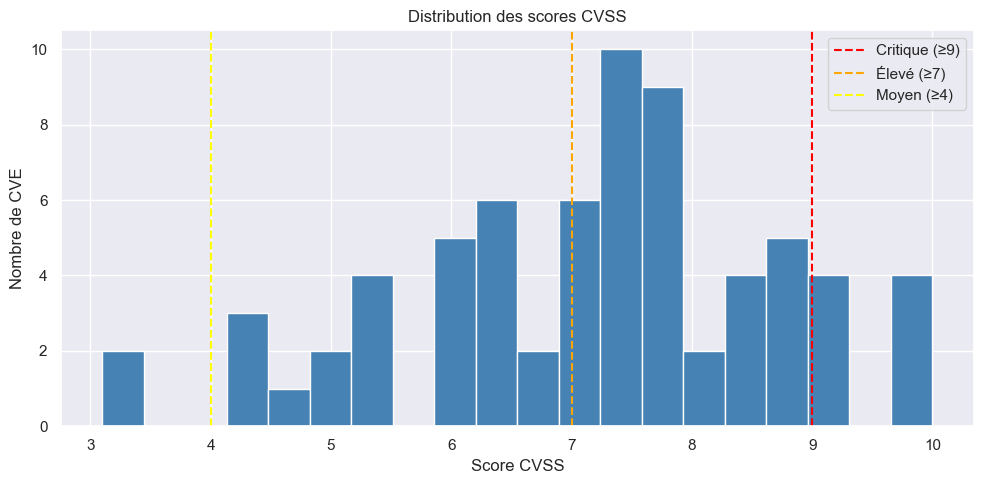

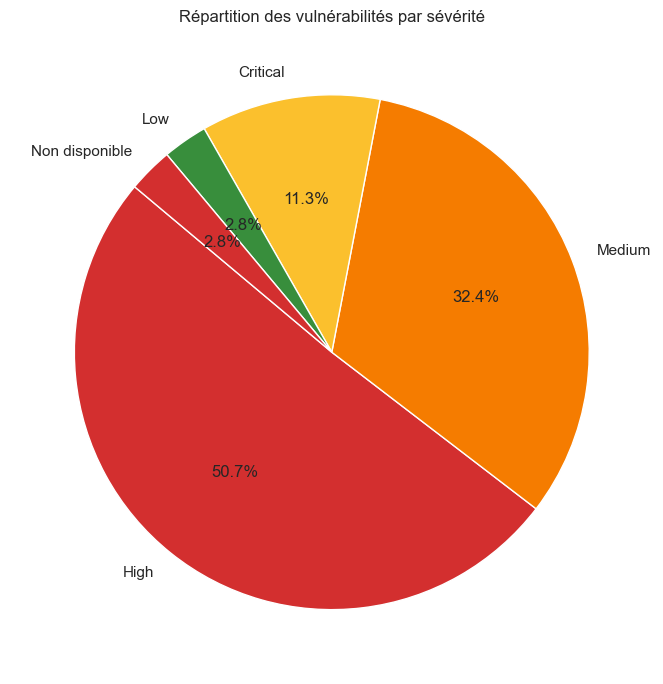

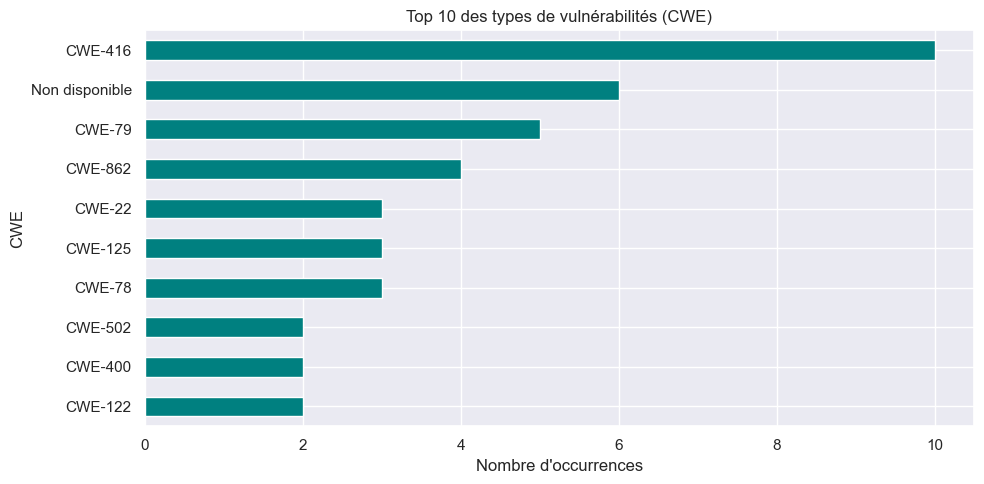

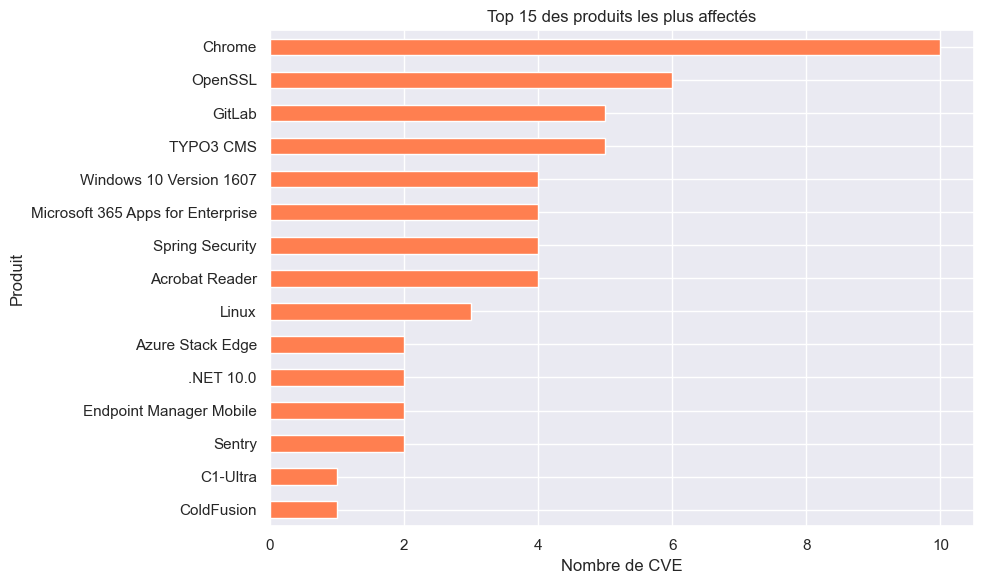

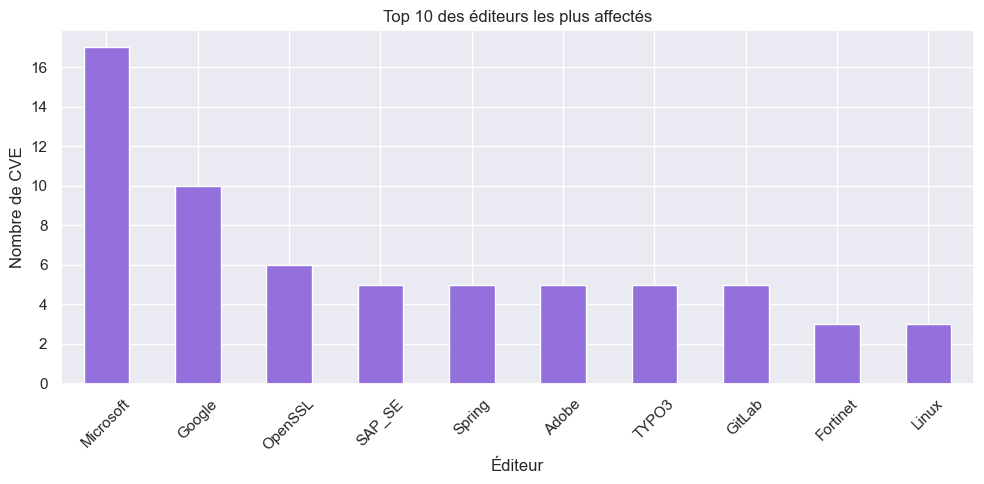

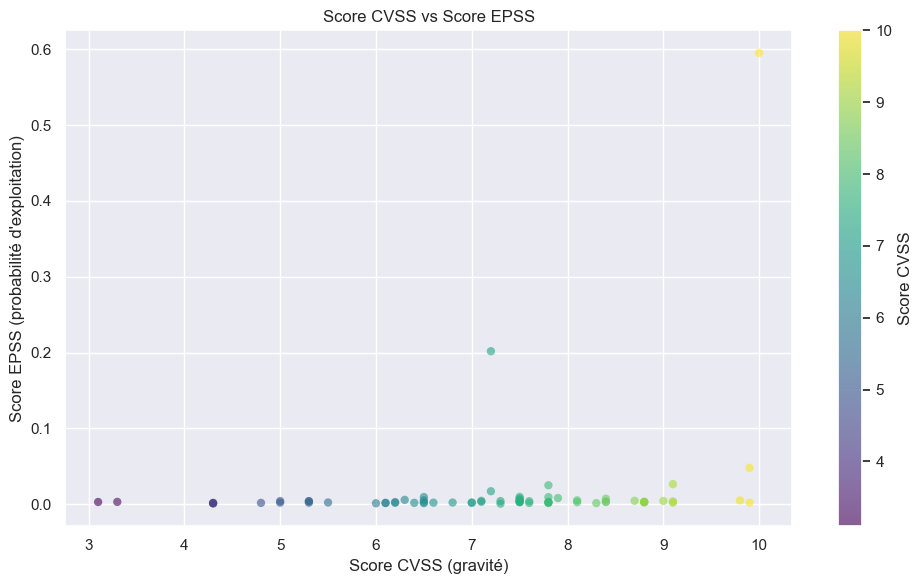

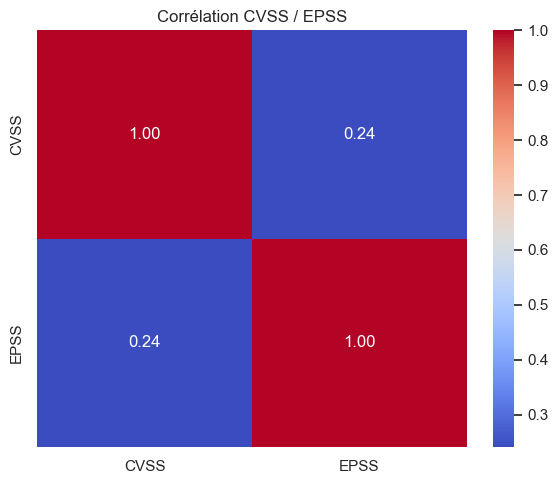

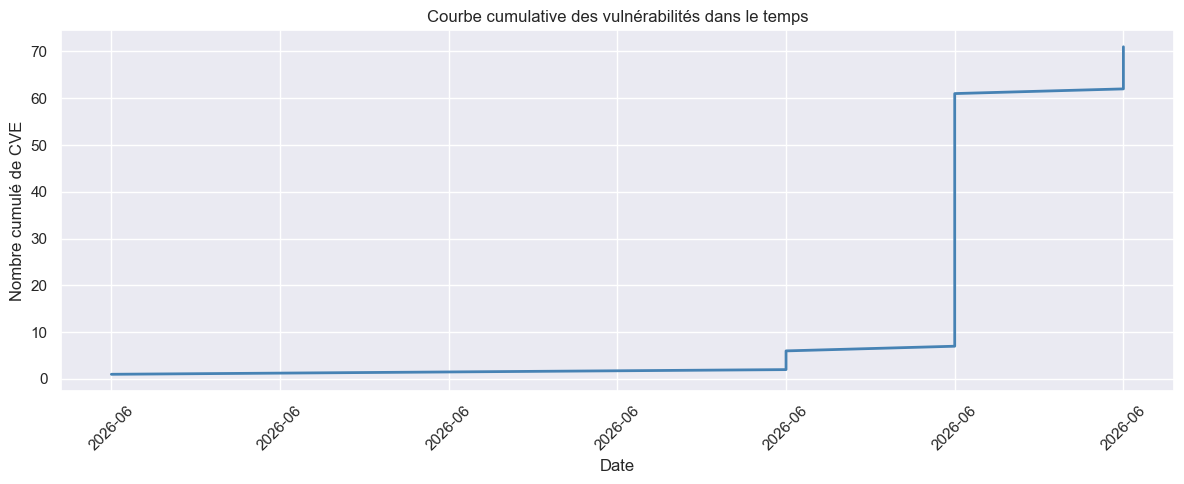

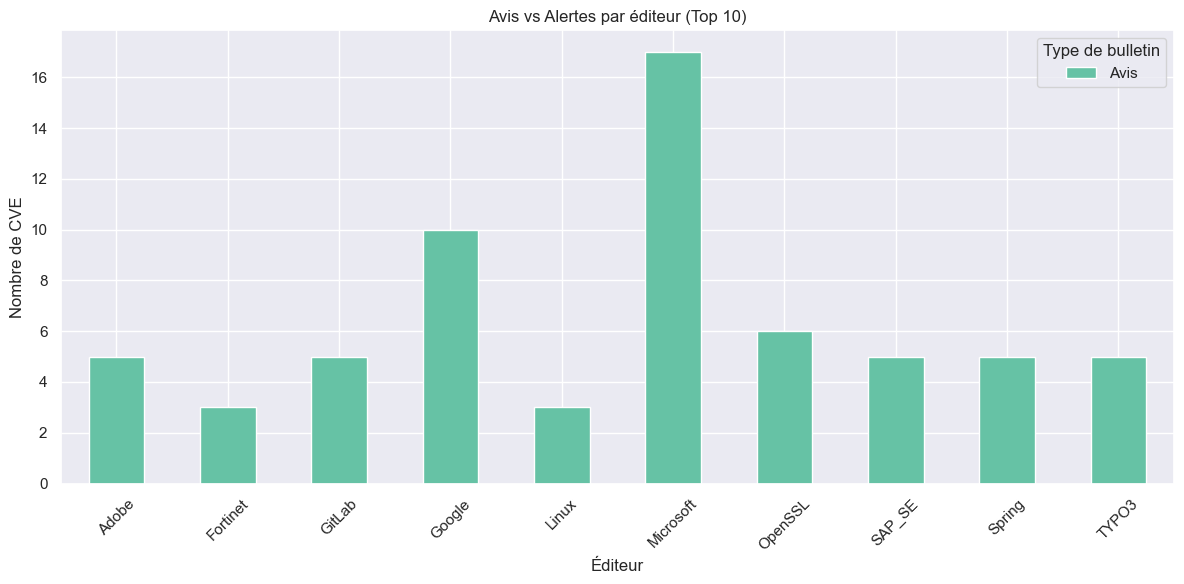

C:\Users\alex2\AppData\Local\Temp\ipykernel_36764\744079166.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x="Éditeur", y="CVSS", palette="Set3", ax=ax)


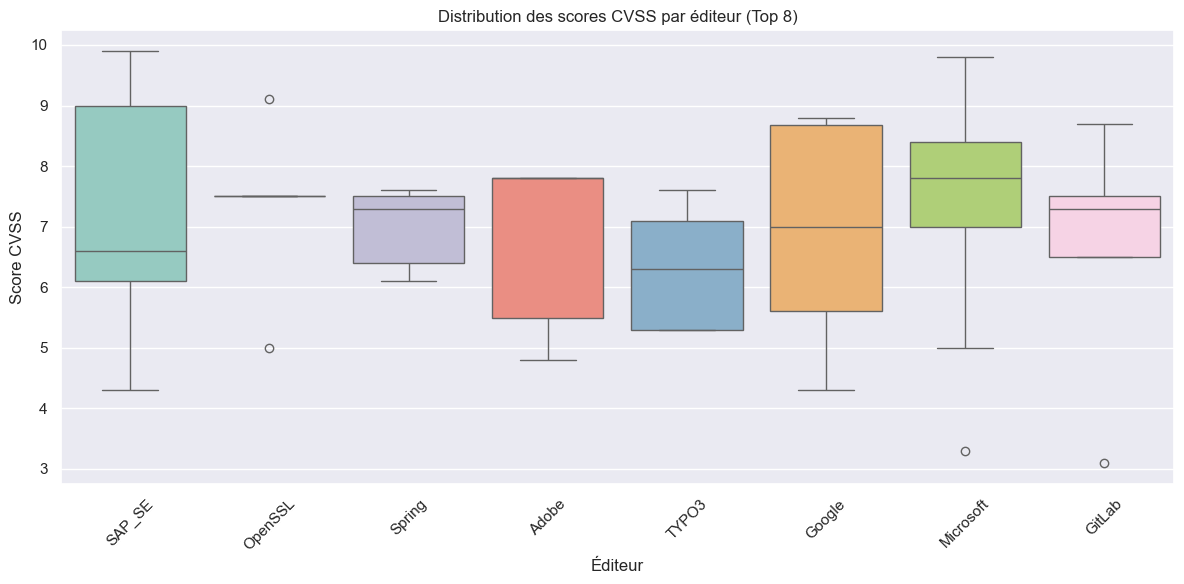

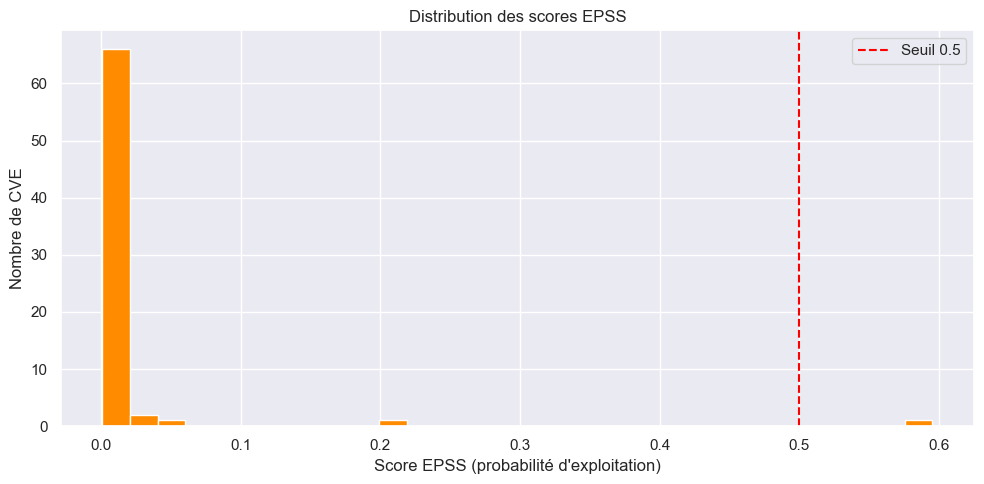

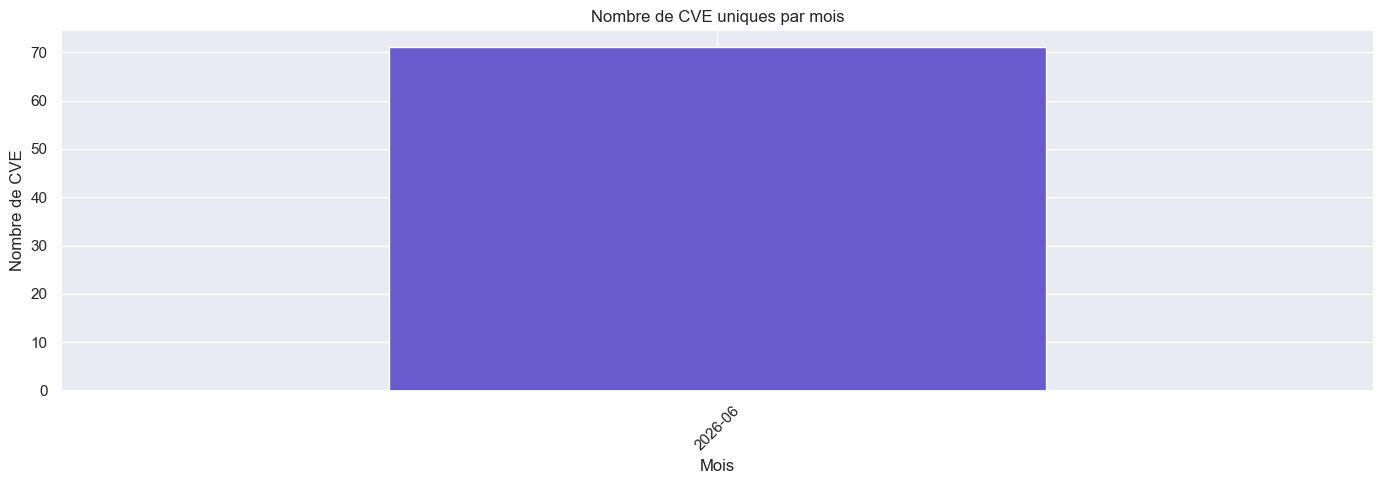

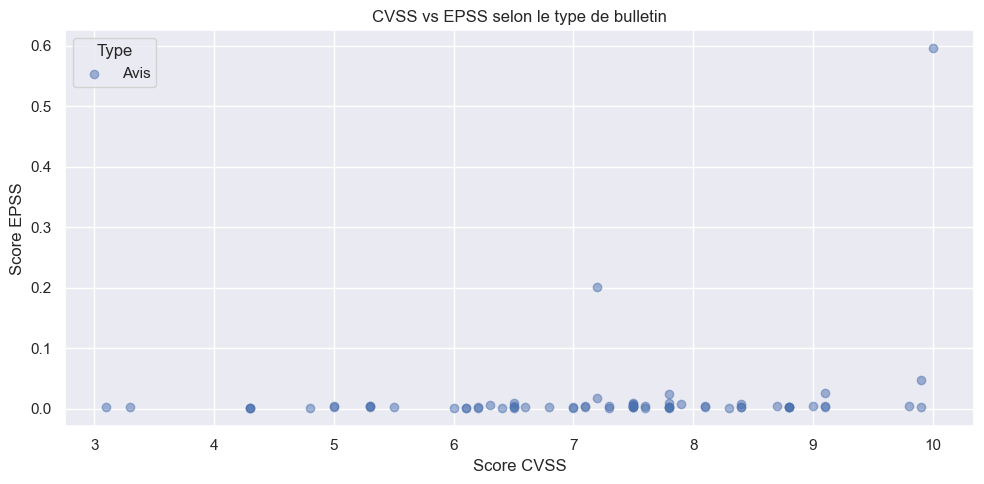

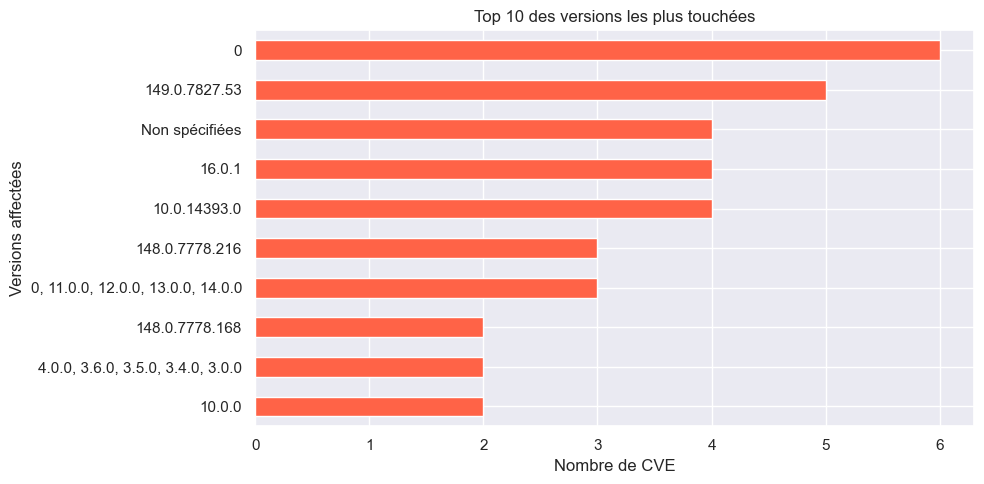

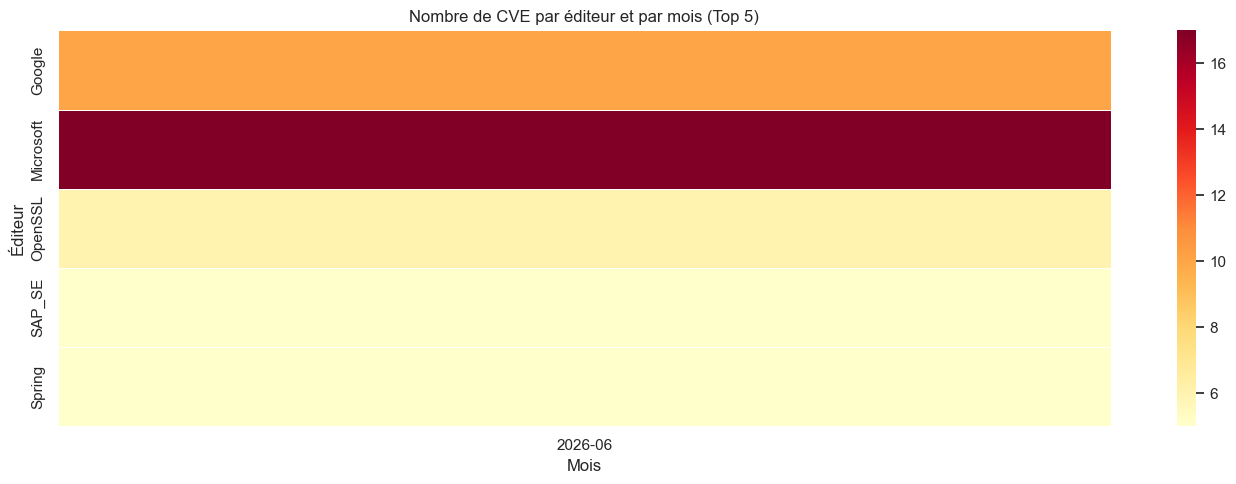


✅ Toutes les visualisations ont été sauvegardées.


In [2]:
"""
Étape 5 : Analyse et Visualisation
====================================
Adapte les noms de colonnes à ton DataFrame.
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np

# ── Chargement ──────────────────────────────────────────────
df = pd.read_csv("donnees_consolidees_anssi.csv", sep=";")

# Conversions de types (adapte les noms)
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["CVSS"] = pd.to_numeric(df["CVSS"], errors="coerce")
df["EPSS"] = pd.to_numeric(df["EPSS"], errors="coerce")

# ── Palette & style global ───────────────────────────────────
sns.set_theme(style="darkgrid")
PALETTE = "viridis"


# ════════════════════════════════════════════════════════════
# 1. HISTOGRAMME — Distribution des scores CVSS
# ════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["CVSS"].dropna(), bins=20, color="steelblue", edgecolor="white")
ax.axvline(9, color="red",    linestyle="--", label="Critique (≥9)")
ax.axvline(7, color="orange", linestyle="--", label="Élevé (≥7)")
ax.axvline(4, color="yellow", linestyle="--", label="Moyen (≥4)")
ax.set_title("Distribution des scores CVSS")
ax.set_xlabel("Score CVSS")
ax.set_ylabel("Nombre de CVE")
ax.legend()
plt.tight_layout()
plt.savefig("viz_01_hist_cvss.png", dpi=150)
plt.show()


# ════════════════════════════════════════════════════════════
# 2. CAMEMBERT — Répartition par niveau de sévérité
# ════════════════════════════════════════════════════════════
severity_counts = df["Base Severity"].value_counts()  # adapte le nom de colonne

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    severity_counts,
    labels=severity_counts.index,
    autopct="%1.1f%%",
    colors=["#d32f2f", "#f57c00", "#fbc02d", "#388e3c"],
    startangle=140,
)
ax.set_title("Répartition des vulnérabilités par sévérité")
plt.tight_layout()
plt.savefig("viz_02_pie_severity.png", dpi=150)
plt.show()


# ════════════════════════════════════════════════════════════
# 3. BARPLOT — Top 10 types CWE les plus fréquents
# ════════════════════════════════════════════════════════════
top_cwe = df["CWE"].value_counts().head(10)  # adapte le nom de colonne

fig, ax = plt.subplots(figsize=(10, 5))
top_cwe.plot(kind="barh", ax=ax, color="teal")
ax.set_title("Top 10 des types de vulnérabilités (CWE)")
ax.set_xlabel("Nombre d'occurrences")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("viz_03_bar_cwe.png", dpi=150)
plt.show()


# ════════════════════════════════════════════════════════════
# 4. BARPLOT — Top 15 produits les plus affectés
# ════════════════════════════════════════════════════════════
top_products = df["Produit"].value_counts().head(15)  # adapte le nom de colonne

fig, ax = plt.subplots(figsize=(10, 6))
top_products.plot(kind="barh", ax=ax, color="coral")
ax.set_title("Top 15 des produits les plus affectés")
ax.set_xlabel("Nombre de CVE")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("viz_04_bar_products.png", dpi=150)
plt.show()


# ════════════════════════════════════════════════════════════
# 5. BARPLOT — Top 10 éditeurs (vendors) les plus affectés
# ════════════════════════════════════════════════════════════
top_vendors = df["Éditeur"].value_counts().head(10)  # adapte le nom de colonne

fig, ax = plt.subplots(figsize=(10, 5))
top_vendors.plot(kind="bar", ax=ax, color="mediumpurple")
ax.set_title("Top 10 des éditeurs les plus affectés")
ax.set_ylabel("Nombre de CVE")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("viz_05_bar_vendors.png", dpi=150)
plt.show()


# ════════════════════════════════════════════════════════════
# 6. NUAGE DE POINTS — CVSS vs EPSS
# ════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    df["CVSS"],
    df["EPSS"],
    c=df["CVSS"],
    cmap=PALETTE,
    alpha=0.6,
    edgecolors="none",
)
plt.colorbar(scatter, ax=ax, label="Score CVSS")
ax.set_title("Score CVSS vs Score EPSS")
ax.set_xlabel("Score CVSS (gravité)")
ax.set_ylabel("Score EPSS (probabilité d'exploitation)")
plt.tight_layout()
plt.savefig("viz_06_scatter_cvss_epss.png", dpi=150)
plt.show()


# ════════════════════════════════════════════════════════════
# 7. HEATMAP — Corrélation entre variables numériques
# ════════════════════════════════════════════════════════════
cols_num = df[["CVSS", "EPSS"]].dropna()  # ajoute d'autres colonnes num si tu en as

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cols_num.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Corrélation CVSS / EPSS")
plt.tight_layout()
plt.savefig("viz_07_heatmap_corr.png", dpi=150)
plt.show()


# ════════════════════════════════════════════════════════════
# 8. COURBE CUMULATIVE — Évolution temporelle des CVE
# ════════════════════════════════════════════════════════════
df_time = df.dropna(subset=["Date"]).sort_values("Date")
df_time["cumul"] = range(1, len(df_time) + 1)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_time["Date"], df_time["cumul"], color="steelblue", linewidth=2)
ax.set_title("Courbe cumulative des vulnérabilités dans le temps")
ax.set_xlabel("Date")
ax.set_ylabel("Nombre cumulé de CVE")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("viz_08_cumul_time.png", dpi=150)
plt.show()


# ════════════════════════════════════════════════════════════
# 9. BARPLOT GROUPÉ — Avis vs Alertes par éditeur (top 10)
# ════════════════════════════════════════════════════════════
top_v = df["Éditeur"].value_counts().head(10).index
df_top = df[df["Éditeur"].isin(top_v)]

pivot = df_top.groupby(["Éditeur", "Type"]).size().unstack(fill_value=0)  # adapte "type"

fig, ax = plt.subplots(figsize=(12, 6))
pivot.plot(kind="bar", ax=ax, colormap="Set2")
ax.set_title("Avis vs Alertes par éditeur (Top 10)")
ax.set_ylabel("Nombre de CVE")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Type de bulletin")
plt.tight_layout()
plt.savefig("viz_09_grouped_vendor_type.png", dpi=150)
plt.show()


# ════════════════════════════════════════════════════════════
# 10. BOXPLOT — Distribution des scores CVSS par éditeur (top 8)
# ════════════════════════════════════════════════════════════
top8 = df["Éditeur"].value_counts().head(8).index
df_box = df[df["Éditeur"].isin(top8)]

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_box, x="Éditeur", y="CVSS", palette="Set3", ax=ax)
ax.set_title("Distribution des scores CVSS par éditeur (Top 8)")
ax.set_xlabel("Éditeur")
ax.set_ylabel("Score CVSS")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("viz_10_boxplot_cvss_vendor.png", dpi=150)
plt.show()


# ════════════════════════════════════════════════════════════
# 11. HISTOGRAMME — Distribution des scores EPSS
# ════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["EPSS"].dropna(), bins=30, color="darkorange", edgecolor="white")
ax.axvline(0.5, color="red", linestyle="--", label="Seuil 0.5")
ax.set_title("Distribution des scores EPSS")
ax.set_xlabel("Score EPSS (probabilité d'exploitation)")
ax.set_ylabel("Nombre de CVE")
ax.legend()
plt.tight_layout()
plt.savefig("viz_11_hist_epss.png", dpi=150)
plt.show()


# ════════════════════════════════════════════════════════════
# 12. BARPLOT — Nombre de CVE par mois
# ════════════════════════════════════════════════════════════
df["mois"] = df["Date"].dt.to_period("M")
cve_par_mois = df.groupby("mois")["CVE"].nunique().sort_index()  # adapte "cve_id"

fig, ax = plt.subplots(figsize=(14, 5))
cve_par_mois.plot(kind="bar", ax=ax, color="slateblue")
ax.set_title("Nombre de CVE uniques par mois")
ax.set_xlabel("Mois")
ax.set_ylabel("Nombre de CVE")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("viz_12_cve_par_mois.png", dpi=150)
plt.show()


# ════════════════════════════════════════════════════════════
# 13. SCATTER — EPSS par type de bulletin (avis vs alerte)
# ════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
for btype, group in df.groupby("Type"):  # adapte "Type"
    ax.scatter(group["CVSS"], group["EPSS"], label=btype, alpha=0.5)
ax.set_title("CVSS vs EPSS selon le type de bulletin")
ax.set_xlabel("Score CVSS")
ax.set_ylabel("Score EPSS")
ax.legend(title="Type")
plt.tight_layout()
plt.savefig("viz_13_scatter_type.png", dpi=150)
plt.show()


# ════════════════════════════════════════════════════════════
# 14. BARPLOT — Top 10 versions les plus touchées
# ════════════════════════════════════════════════════════════
top_versions = df["Versions affectées"].value_counts().head(10)  # adapte le nom de colonne

fig, ax = plt.subplots(figsize=(10, 5))
top_versions.plot(kind="barh", ax=ax, color="tomato")
ax.set_title("Top 10 des versions les plus touchées")
ax.set_xlabel("Nombre de CVE")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("viz_14_bar_versions.png", dpi=150)
plt.show()


# ════════════════════════════════════════════════════════════
# 15. HEATMAP — Nombre de CVE par éditeur × mois
# ════════════════════════════════════════════════════════════
top5_vendors = df["Éditeur"].value_counts().head(5).index
df_h = df[df["Éditeur"].isin(top5_vendors)].copy()
df_h["mois_str"] = df_h["Date"].dt.strftime("%Y-%m")

pivot_hm = df_h.groupby(["Éditeur", "mois_str"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_hm, cmap="YlOrRd", linewidths=0.5, ax=ax)
ax.set_title("Nombre de CVE par éditeur et par mois (Top 5)")
ax.set_xlabel("Mois")
ax.set_ylabel("Éditeur")
plt.tight_layout()
plt.savefig("viz_15_heatmap_vendor_mois.png", dpi=150)
plt.show()

print("\n✅ Toutes les visualisations ont été sauvegardées.")